In [2]:
from torchvision import datasets
import torch
data_folder = './data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, train=True, download=True)
# carrega os dados

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
x_train = fmnist.data
y_train = fmnist.targets
# carrego as imagens de treino e os rótulos de treino

In [5]:
from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn

In [6]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28)/255# normaliza os dados pois os dados vem em array de 0 a 255 e é dividid por 255 para deixar no intervalo de 0-1
        self.x,self.y = x, y

    def __len__(self):# premite saber quantas amostras o x_train possui
        return len(self.x)

    def __getitem__(self, idx):# dado um indice dde entrada, retorna o indice exato da imagem e do label da mesma
        x,y = self.x[idx], self.y[idx]

        return x, y

In [7]:
from torch.optim import Adam
def get_model():
    # camadas da rede neural
    model = nn.Sequential(
        nn.Linear(28*28, 1000),     
        # recebe todos os pixels como entradas
        nn.ReLU(),
        nn.Linear(1000, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10),
        nn.ReLU(),

    )
    loss = nn.CrossEntropyLoss()
    # funcao de loss
    optimizer = Adam(model.parameters(), lr=0.001)
    # o adam é o otimizador mais estavel e utilizado

    return model, loss, optimizer

In [8]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()# cria o objeto moelo treino
    prediction = model(x)# faz a predicao do modelo apos ser treinado
    batch_loss = loss_fn(prediction, y)# utiliza a funcao de loss para calcular os pesos apos a passada
    batch_loss.backward()
    opt.step()# otimizador aplica a alteração dos pesos
    opt.zero_grad()# zera o greaadiente
    return batch_loss.item()


def accuracy(x,y,model):# cra uma funcao para calcular a acccuracua com os dados e teste
    model.eval() # coloca o modelo em status de avaliação
    with torch.no_grad():
        predict = model(x)# faz a preiçaõ por batch
    max_values, max_indices = predict.max(-1)# pega o maior valor da probabilidade e recebe o indice da classe
    is_correct = max_indices == y # tensor com True de qual classe acertou e False qual errou
    return is_correct.cpu().numpy().tolist()# transforma em lista numpy

In [9]:
@torch.no_grad()
def val_loss(x,y,model):
    predict = model(x)
    val_loss = loss(predict,y)
    return val_loss.item()

In [10]:
def get_data():
    train = FMNISTDataset(x_train, y_train)
    train_loader = DataLoader(train, batch_size=32, shuffle=True)# separa o dataset em batches dde 32 imagens e seus rotulos
    val = FMNISTDataset(x_train, y_train)
    val_dl=DataLoader(val,batch_size=len(x_train),shuffle=False)
    return train_loader, val_dl

In [11]:
train_loader,val_dl = get_data()
model, loss_fn, opt = get_model()
# pega o model, a funcao de perda e o otimizador

In [12]:
losses, accuracies = [], []
val_losses = []
val_accs = []
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    # treina o modelo para 5 epocas
    for ix, batch in enumerate(iter(train_loader)):
        x, y = batch
        batch_loss = train_batch(x, y, model, opt, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    # treina o modelo e ajusta os pesos da rede neural para cada batch de imagens

    for ix, batch in enumerate(iter(train_loader)):
        # utiliza o modelo treinado para calcular a acuracia do modelo para cada batch de imagens
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)

    val_epoch_accuracies = []
    val_epoch_losses = []
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        model.eval()
        with torch.no_grad():
            pred = model(x)
            validation_loss = loss_fn(pred, y)
        val_epoch_losses.append(validation_loss.item())
        val_epoch_accuracies.extend(is_correct)

    val_epoch_accuracy = np.mean(val_epoch_accuracies)
    val_epoch_loss = np.mean(val_epoch_losses)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)
    val_losses.append(val_epoch_loss)
    val_accs.append(val_epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_12544/2994044341.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


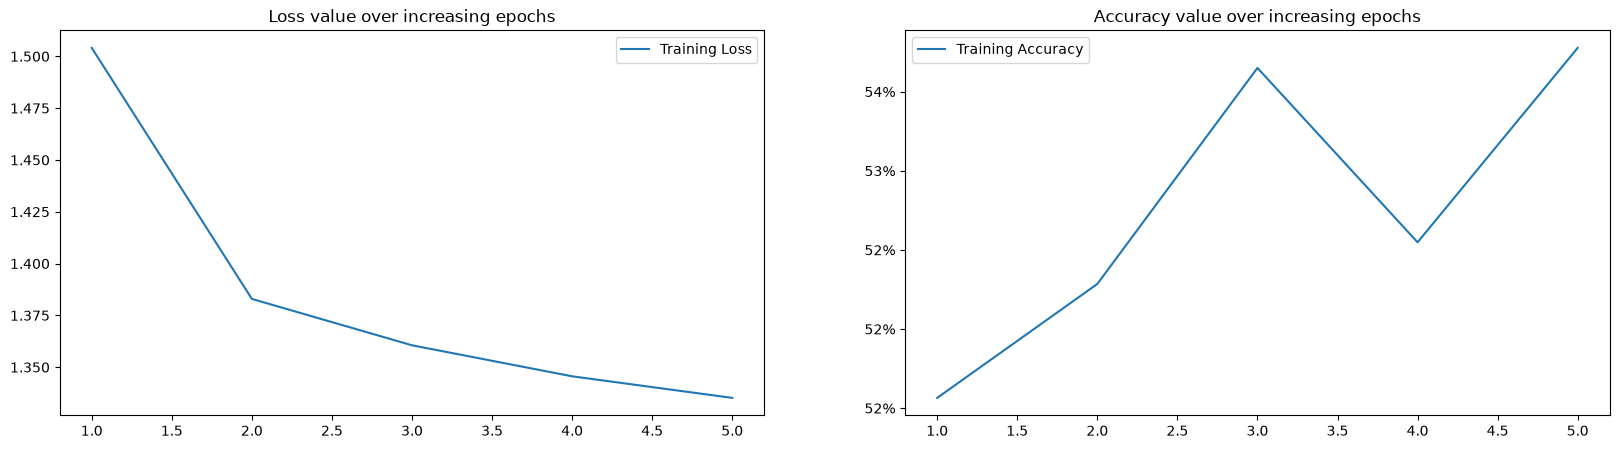

In [ ]:
epochs = np.arange(5)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()